In [21]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
pulls_one = pd.read_csv('datasets/pulls_2011-2013.csv')
pulls_two = pd.read_csv('datasets/pulls_2014-2018.csv')
pull_files = pd.read_csv('datasets/pull_files.csv')

In [23]:
pulls = pd.concat([pulls_one, pulls_two])
pulls['date'] = pd.to_datetime(pulls['date'], utc=True)

In [24]:
data = pulls.merge(pull_files, on='pid')

data.head()

,pid,user,date,file
0,11166973,VladimirNik,2013-12-31 23:10:55+00:00,src/reflect/scala/reflect/api/Printers.scala
1,11166973,VladimirNik,2013-12-31 23:10:55+00:00,src/reflect/scala/reflect/internal/Printers.scala
2,11166973,VladimirNik,2013-12-31 23:10:55+00:00,test/files/run/reify_ann3.check
3,11166973,VladimirNik,2013-12-31 23:10:55+00:00,test/junit/scala/reflect/internal/PrintersTest...
4,11161892,Ichoran,2013-12-31 16:55:47+00:00,src/library/scala/collection/mutable/ArrayOps....


In [25]:
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month

In [26]:
monthly_activity = data.groupby(['year','month'])['pid'].count().reset_index()
monthly_activity['date'] = pd.to_datetime(monthly_activity[['year','month']].assign(day=1))

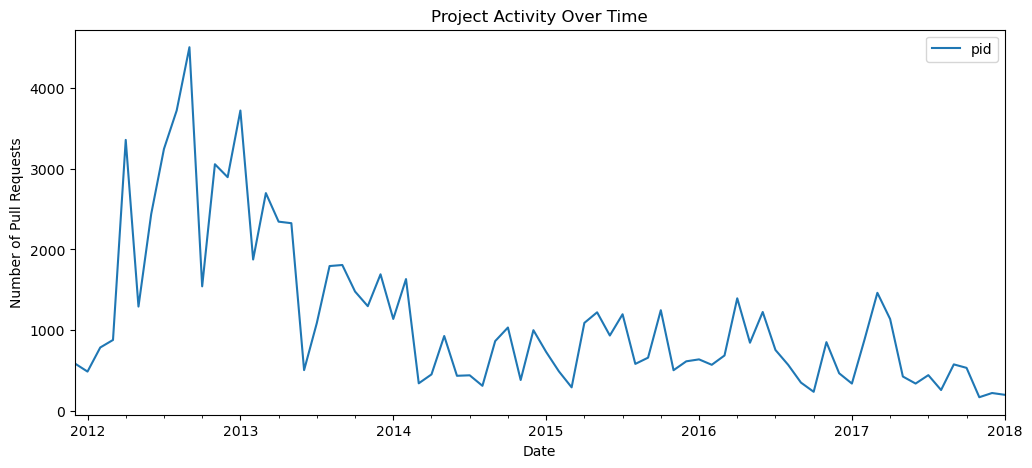

In [27]:
monthly_activity.plot(x='date', y='pid', figsize=(12,5), title='Project Activity Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Pull Requests')
plt.show()

In [28]:
by_user = data.groupby('user')['pid'].count().reset_index(name='pull_count')

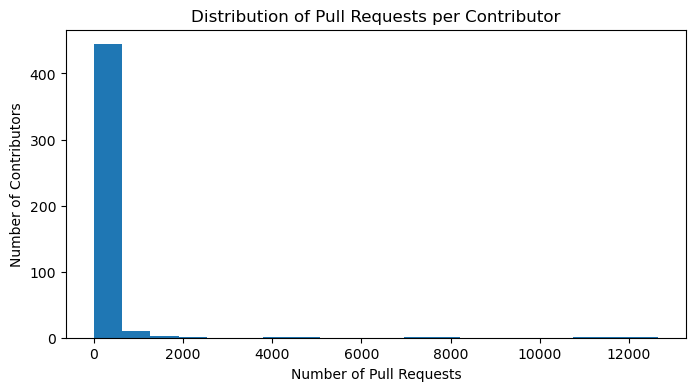

In [29]:
by_user['pull_count'].plot(kind='hist', bins=20, figsize=(8,4), title='Distribution of Pull Requests per Contributor')
plt.xlabel('Number of Pull Requests')
plt.ylabel('Number of Contributors')
plt.show()

In [30]:
last_10 = pulls.sort_values('date').tail(10)
last_10_joined = last_10.merge(pull_files, on='pid')
recent_files = set(last_10_joined['file'].unique())
print("Files modified in the last 10 PRs:")
print(recent_files)

Files modified in the last 10 PRs:
{'src/library/scala/util/Properties.scala', 'test/files/pos/t10568/Converter.java', 'src/compiler/scala/tools/nsc/typechecker/Contexts.scala', 'src/library/scala/Predef.scala', 'src/compiler/scala/reflect/reify/phases/Calculate.scala', 'test/files/pos/parallel-classloader.scala', 'src/compiler/scala/tools/nsc/backend/jvm/analysis/BackendUtils.scala', 'doc/LICENSE.md', 'doc/License.rtf', 'src/compiler/scala/tools/nsc/symtab/classfile/ClassfileParser.scala', 'test/files/pos/t10568/Impl.scala', 'test/files/pos/t5638/Among.java', 'LICENSE', 'test/files/run/t8348/TableColumn.java', 'src/compiler/scala/tools/nsc/backend/jvm/PostProcessor.scala', 'test/files/run/t8348/Test.scala', 'test/files/pos/leibniz_liskov.scala', 'src/reflect/scala/reflect/internal/pickling/ByteCodecs.scala', 'test/files/pos/t9291.scala', 'src/library/scala/concurrent/Lock.scala', 'src/scaladoc/scala/tools/nsc/doc/html/page/Entity.scala', 'src/compiler/scala/tools/nsc/profile/AsyncHelp

In [31]:
file = 'src/compiler/scala/reflect/reify/phases/Calculate.scala'
file_pr = data[data['file'] == file]
author_counts = file_pr.groupby('user')['pid'].count().reset_index(name='changes').sort_values('changes', ascending=False)
print("Top 3 contributors to the file:")
print(author_counts.head(3))

Top 3 contributors to the file:
       user  changes
9   xeno-by       11
6  retronym        5
7       soc        4


In [32]:
last_file_pr = file_pr.sort_values('date', ascending=False).head(10)
users_last_10 = last_file_pr[['user', 'date']]
print("Last 10 contributors and dates:")
print(users_last_10)

Last 10 contributors and dates:
               user                      date
51415     zuvizudar 2018-01-14 19:16:16+00:00
78353      retronym 2014-10-16 10:23:42+00:00
84155       xeno-by 2014-02-01 01:19:58+00:00
1234       retronym 2013-12-06 10:04:43+00:00
12514           soc 2013-04-23 15:47:45+00:00
12823  bjornregnell 2013-04-22 13:56:06+00:00
13381      retronym 2013-04-09 06:13:57+00:00
13779      retronym 2013-04-08 07:07:45+00:00
14970     starblood 2013-03-25 02:48:48+00:00
17127      retronym 2013-02-24 21:43:43+00:00


C:\Users\HP\AppData\Local\Temp\ipykernel_20292\942686496.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  by_author['year'] = by_author['date'].dt.year


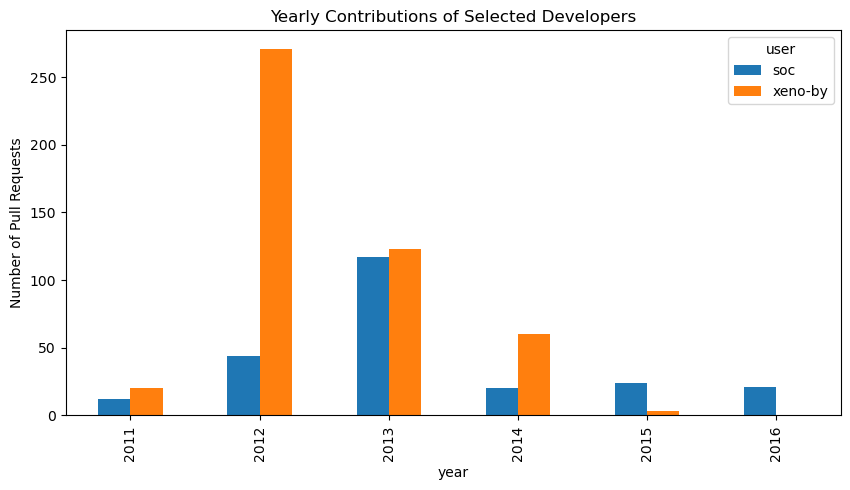

In [33]:
authors = ['xeno-by', 'soc']
by_author = pulls[pulls['user'].isin(authors)]
by_author['year'] = by_author['date'].dt.year
counts = by_author.groupby(['year','user'])['pid'].count().reset_index()
counts_wide = counts.pivot(index='year', columns='user', values='pid').fillna(0)
counts_wide.plot(kind='bar', figsize=(10,5), title='Yearly Contributions of Selected Developers')
plt.ylabel('Number of Pull Requests')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_20292\218933301.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  file_authors['year'] = file_authors['date'].dt.year


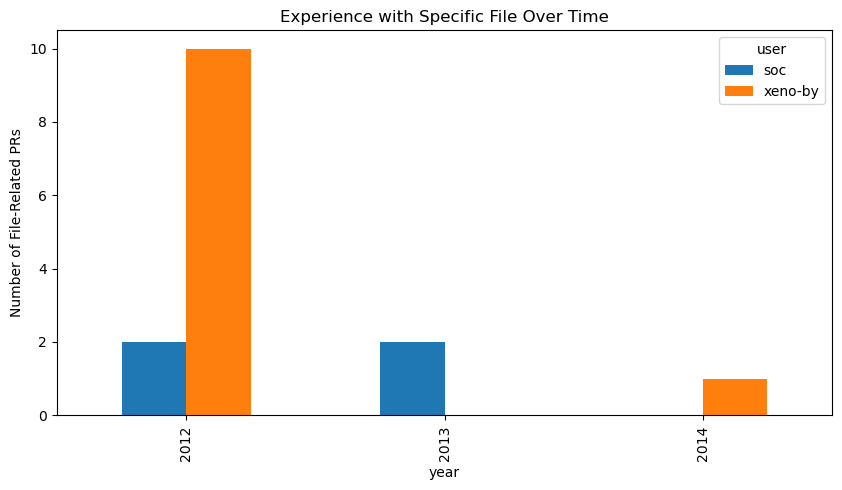

In [20]:
file_data = data[data['file'] == file]
file_authors = file_data[file_data['user'].isin(authors)]
file_authors['year'] = file_authors['date'].dt.year
grouped = file_authors.groupby(['user','year'])['pid'].count().reset_index()
by_file_wide = grouped.pivot(index='year', columns='user', values='pid').fillna(0)

by_file_wide.plot(kind='bar', figsize=(10,5), title='Experience with Specific File Over Time')
plt.ylabel('Number of File-Related PRs')
plt.show()